In [1]:
import sys
import os

# _miqp_dir  = uavsafeplanning/MIQP/   (MIQP_MINCO_solver etc.)
# _parent_dir = uavsafeplanning/        (traj_gen_utils package)
_miqp_dir   = os.path.abspath("")
_parent_dir = os.path.dirname(_miqp_dir)

for _p in [_miqp_dir, _parent_dir]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

# Change working directory to uavsafeplanning/ so that relative file paths
# like "traj_gen_utils/data/forest.txt" resolve correctly.
os.chdir(_parent_dir)

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from traj_gen_utils import MINCO_S3NU

from traj_gen_utils import load_voxel_grid
import pyvista as pv
pv.set_jupyter_backend('html')

# load voxel grid environment
path = "traj_gen_utils/data/forest.txt"
vg = load_voxel_grid(path, padding=0)
vg.plot_pyvista()
grid3D = vg.grid

from traj_gen_utils import astar_3d, visualize

start = (1, 5, 10)
goal = (90, 90, 10)
start_grid_idx = vg.info.to_index(start)
goal_grid_idx = vg.info.to_index(goal)

path_indices = astar_3d(grid3D, start_grid_idx, goal_grid_idx, connectivity=18)
visualize(vg, path_indices)

import pydecomp as pdc
from traj_gen_utils import visualize_voxelgrid_with_path
from traj_gen_utils import reduce_turns_by_los

# prune path to only keep straight line segments
path = reduce_turns_by_los(np.array(path_indices), grid3D)

origin    = np.asarray(vg.info.origin, dtype=np.float64)
occ_idx   = np.argwhere(vg.grid == 1)
obs_np    = (occ_idx + 0.5).astype(np.float64) + origin
path_np   = (np.asarray(path, np.float64) + 0.5) + origin 
box_np    = np.array([[5.0, 5.0, 5.0]], dtype=np.float64)

A_list, b_list = pdc.convex_decomposition_3D(obs_np, path_np, box_np)
# (A_list, b_list) is a list of half-space representations of convex polytopes

visualize_voxelgrid_with_path(vg, path_indices, A_list=A_list, b_list=b_list)


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

[viz] surf points/cells: 128248 128848
[viz] surf bounds: BoundsTuple(x_min =   0.0,
            x_max = 100.0,
            y_min =   0.0,
            y_max = 100.0,
            z_min =   0.0,
            z_max =  40.0)
[viz] centers min/max: [ 1.5  5.5 10.5] [91.5 90.5 10.5]
[viz] segments: 5


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

In [2]:
##########################################
### STEP 1: Environment Setup (Continued)
##########################################

print("="*60)
print("ENVIRONMENT SETUP - COMMON PARAMETERS")
print("="*60)

# Number of corridors (from convex decomposition)
n_corridors = len(A_list)
print(f"\n[1] Safe Flight Corridors: {n_corridors} corridors")
for i, (A, b) in enumerate(zip(A_list, b_list)):
    print(f"    Corridor {i}: {A.shape[0]} half-space constraints")

# Number of segments (MUST BE SAME FOR BOTH METHODS)
n_segments = n_corridors  # N = 5 segments
print(f"\n[2] Trajectory Segmentation: N = {n_segments} segments")

# Waypoints from A* path
waypoints_init = path_np[1:-1]  # Exclude start and goal
n_waypoints = len(waypoints_init)
print(f"    Intermediate waypoints: {n_waypoints} (N-1)")
print(f"    Start point: [{path_np[0][0]:.2f}, {path_np[0][1]:.2f}, {path_np[0][2]:.2f}]")
for i, wp in enumerate(waypoints_init):
    print(f"    Waypoint {i}: [{wp[0]:.2f}, {wp[1]:.2f}, {wp[2]:.2f}]")
print(f"    Goal point:  [{path_np[-1][0]:.2f}, {path_np[-1][1]:.2f}, {path_np[-1][2]:.2f}]")

# Boundary Conditions (SAME FOR BOTH METHODS)
pos_init = path_np[0]       # Start position
vel_init = np.array([0.0, 0.0, 0.0])   # Start velocity
acc_init = np.array([0.0, 0.0, 0.0])   # Start acceleration

pos_final = path_np[-1]     # Goal position
vel_final = np.array([0.0, 0.0, 0.0])  # Goal velocity
acc_final = np.array([0.0, 0.0, 0.0])  # Goal acceleration

print(f"\n[3] Boundary Conditions:")
print(f"    Initial: P={pos_init}, V={vel_init}, A={acc_init}")
print(f"    Final:   P={pos_final}, V={vel_final}, A={acc_final}")

# Dynamic Limits (SAME FOR BOTH METHODS)
v_max = 2.0   # m/s - maximum velocity
a_max = 1.0   # m/s² - maximum acceleration


print(f"\n[4] Dynamic Limits:")
print(f"    Max velocity:     v_max = {v_max} m/s")
print(f"    Max acceleration: a_max = {a_max} m/s²")
print(f"    Jerk: unconstrained (minimized as objective)")

# Calculate segment lengths (for time initialization)
segment_lengths = []
segment_lengths.append(np.linalg.norm(waypoints_init[0] - path_np[0]))  # start to wp0
for i in range(len(waypoints_init) - 1):
    segment_lengths.append(np.linalg.norm(waypoints_init[i+1] - waypoints_init[i]))
segment_lengths.append(np.linalg.norm(path_np[-1] - waypoints_init[-1]))  # last wp to goal

total_path_length = sum(segment_lengths)

print(f"\n[5] Path Statistics:")
print(f"    Total path length: {total_path_length:.2f} m")
print(f"    Segment lengths: {[f'{l:.2f}' for l in segment_lengths]}")

# Initial time allocation (heuristic based on segment length and max velocity)
time_init = [length / v_max for length in segment_lengths]
total_time_init = sum(time_init)

print(f"    Initial time allocation: {[f'{t:.2f}s' for t in time_init]}")
print(f"    Total initial time: {total_time_init:.2f} s")

print("\n" + "="*60)
print("✓ Environment setup complete!")
print("="*60)

ENVIRONMENT SETUP - COMMON PARAMETERS

[1] Safe Flight Corridors: 5 corridors
    Corridor 0: 14 half-space constraints
    Corridor 1: 10 half-space constraints
    Corridor 2: 8 half-space constraints
    Corridor 3: 10 half-space constraints
    Corridor 4: 8 half-space constraints

[2] Trajectory Segmentation: N = 5 segments
    Intermediate waypoints: 4 (N-1)
    Start point: [1.50, 5.50, 10.50]
    Waypoint 0: [23.50, 24.50, 10.50]
    Waypoint 1: [61.50, 60.50, 10.50]
    Waypoint 2: [64.50, 61.50, 10.50]
    Waypoint 3: [91.50, 88.50, 10.50]
    Goal point:  [90.50, 90.50, 10.50]

[3] Boundary Conditions:
    Initial: P=[ 1.5  5.5 10.5], V=[0. 0. 0.], A=[0. 0. 0.]
    Final:   P=[90.5 90.5 10.5], V=[0. 0. 0.], A=[0. 0. 0.]

[4] Dynamic Limits:
    Max velocity:     v_max = 2.0 m/s
    Max acceleration: a_max = 1.0 m/s²
    Jerk: unconstrained (minimized as objective)

[5] Path Statistics:
    Total path length: 125.00 m
    Segment lengths: ['29.07', '52.35', '3.16', '38.18', '

In [3]:
##########################################
### STEP 2: STO Implementation
##########################################

from sto_planner import STOPlanner

# ── Adaptive weight settings ──────────────────────────────────────────────────
# When adaptive_weights=True the solver uses a sequential penalty approach:
#   Phase 1: constraint weights = lambda / scale^(phases-1)  → light penalty
#   Phase 2: constraint weights *= scale_factor               → medium penalty
#   ...
#   Phase N: constraint weights = lambda (target)             → full penalty
# The L-BFGS Hessian approximation is reset at every phase boundary.
# This lets the optimizer first find a good trajectory shape, then tighten it
# into constraint satisfaction — avoiding premature local minima.
#
# Set adaptive_weights=False to use fixed weights (original behavior).
USE_ADAPTIVE = True   # ← toggle here

# Create STO planner
planner_sto = STOPlanner(
    n_segments=n_segments,
    A_list=A_list,
    b_list=b_list,
    waypoints_init=waypoints_init,
    time_init=time_init,
    v_max=v_max,
    a_max=a_max,
    lambda_jerk=10.0,       # Jerk energy weight (PRIMARY, constant)
    lambda_time=0.05,       # Total time weight  (constant)
    lambda_vel=120.0,       # Velocity penalty   (target / final phase)
    lambda_acc=5.0,         # Acceleration penalty (target / final phase)
    lambda_corridor=1000.0, # Corridor penalty   (target / final phase)
    learn_rate=0.05,
    max_iter=50,
    verbose=True,
    # ── Adaptive weight parameters ────────────────────────────────────────────
    adaptive_weights=USE_ADAPTIVE,
    weight_phases=3,         # 3 phases → iters split ~17/17/16
    weight_scale_factor=5.0, # weights × 5 at each phase transition
)

# Solve trajectory optimization
planner_sto.solve(
    pos_init=pos_init,
    vel_init=vel_init,
    acc_init=acc_init,
    pos_final=pos_final,
    vel_final=vel_final,
    acc_final=acc_final
)

# Extract results
results_sto = planner_sto.get_results(n_samples=200)

# Print summary
print("\n" + "="*60)
print("STO RESULTS SUMMARY")
print("="*60)
print(f"Runtime:         {results_sto['runtime']:.3f} seconds")
print(f"Total time:      {results_sto['total_time']:.3f} seconds")
print(f"Jerk cost:       {results_sto['jerk_cost']:.6f}")
print(f"\nConstraint Violations:")
print(f"  Velocity:      {results_sto['violations']['vel']:.6f} m/s")
print(f"  Acceleration:  {results_sto['violations']['acc']:.6f} m/s²")
print(f"  Corridor:      {results_sto['violations']['corridor']:.6f} m")
if results_sto['weight_history']:
    print(f"\nAdaptive Weight Schedule:")
    print(f"  {'Phase':>5} | {'Iter start':>10} | {'λ_vel':>10} | {'λ_acc':>8} | {'λ_corridor':>12}")
    print(f"  {'-'*55}")
    for wh in results_sto['weight_history']:
        print(f"  {wh['phase']:>5} | {wh['iter_start']:>10} | "
              f"{wh['lambda_vel']:>10.2f} | {wh['lambda_acc']:>8.2f} | "
              f"{wh['lambda_corridor']:>12.2f}")
print("="*60)

/home/okanarif/repositories/SemesterThesis/uavsafeplanning/STO/sto_planner.py:146: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  self.waypoints = torch.tensor([waypoints_init], dtype=torch.float32, requires_grad=True)


STO TRAJECTORY OPTIMIZATION
Segments:       5
Waypoints:      4
Max iterations: 50
Corridor cost:  L2 penalty
Adaptive weights: ON  (3 phases, ×5.0 per phase)

Objective weights (fixed):
  λ_jerk     = 10.00
  λ_time     = 0.05

Constraint weights (phase 1 / final target):
  λ_vel      = 4.80  →  120.00
  λ_acc      = 0.20  →  5.00
  λ_corridor = 40.00  →  1000.00  [L2]

Iter | Phase |        Total |       Jerk |     Time |        Vel |        Acc |       Corr
--------------------------------------------------------------------------------------------------
   1 |     1 |  1190.372192 |   2.888332 |    56.38 |   1.271696 |   0.035113 |  28.813972
   5 |     1 |     4.013885 |   0.018544 |    73.10 |   0.036179 |   0.000000 |   0.000000
  10 |     1 |     3.993179 |   0.015915 |    73.63 |   0.031196 |   0.000000 |   0.000069
  15 |     1 |     3.993179 |   0.015915 |    73.63 |   0.031196 |   0.000000 |   0.000069

  ── Phase 2/3: λ_vel=24.0  λ_acc=1.0  λ_corridor=200.0  (L-BFGS reset)

Generating STO visualizations...


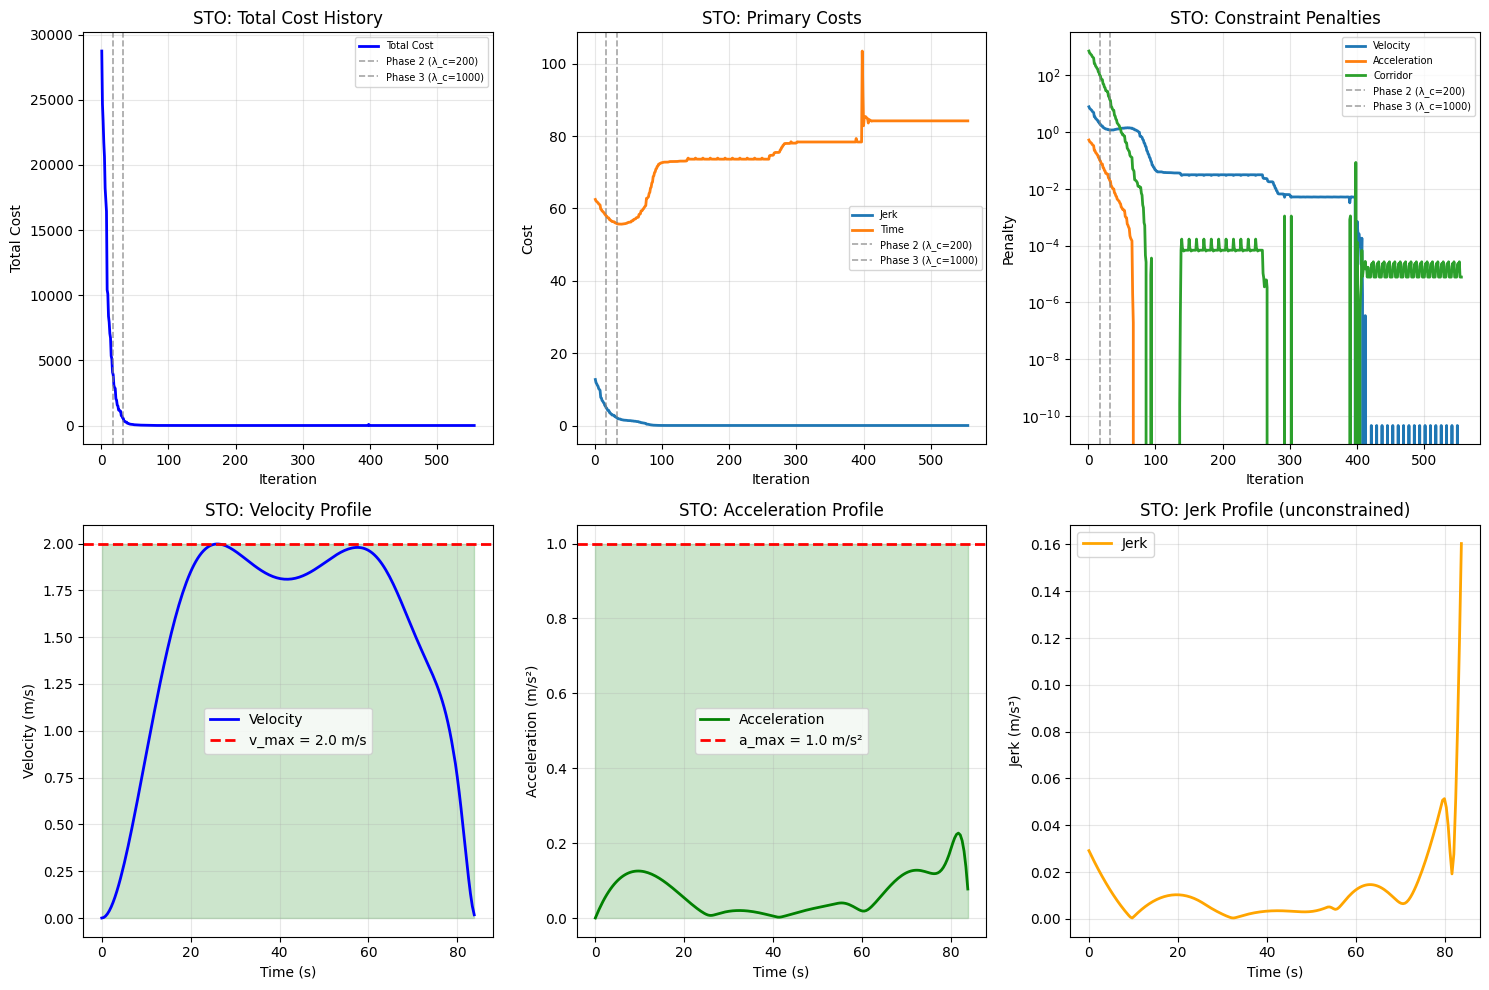

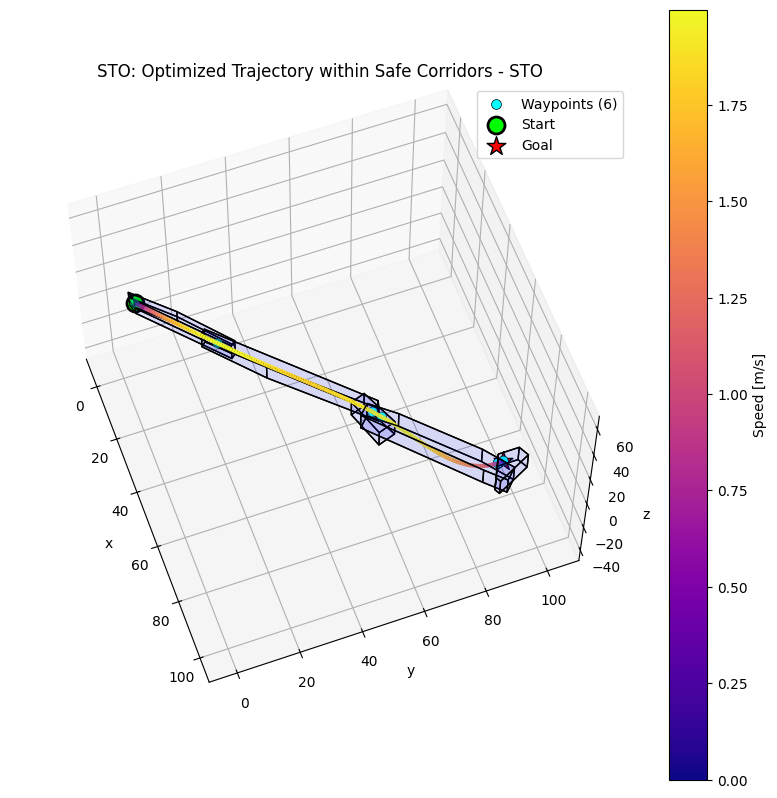

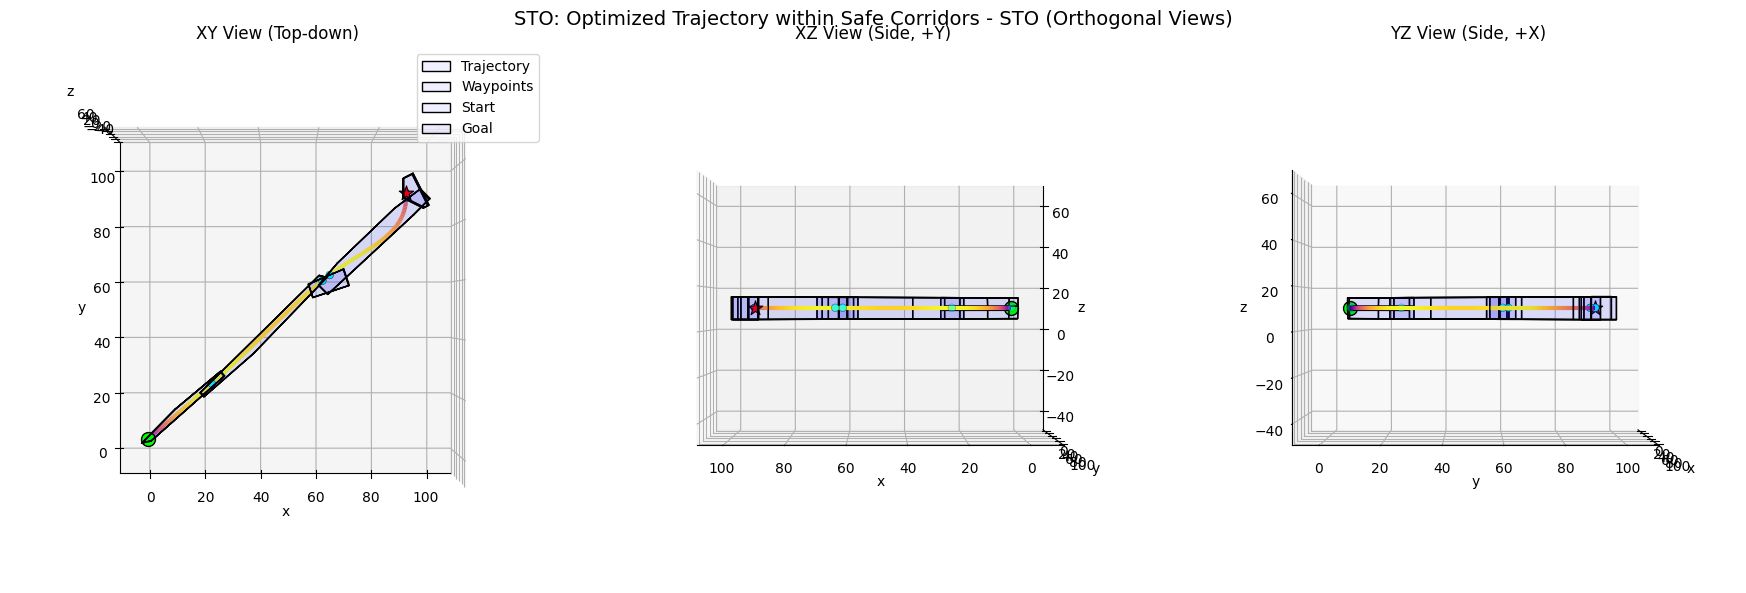

✓ STO visualization complete!


In [4]:
##########################################
### STEP 2.1: STO - Visualization
##########################################

from sto_visualizer import visualize_trajectory_3d, visualize_optimization_metrics

print("Generating STO visualizations...")

# 1) Optimization metrics (cost history + dynamic profiles)
#    weight_history draws vertical phase-boundary lines when adaptive_weights=True
visualize_optimization_metrics(
    cost_history=results_sto['cost_history'],
    t_eval=results_sto['t_eval'],
    vel_norm=results_sto['vel_norm'],
    acc_norm=results_sto['acc_norm'],
    jerk_norm=results_sto['jerk_norm'],
    v_max=v_max,
    a_max=a_max,
    method_name="STO",
    weight_history=results_sto.get('weight_history'),
)

# 2) 3D trajectory visualization
waypoints_with_boundaries = np.vstack([
    pos_init,
    results_sto['waypoints'],
    pos_final
])

visualize_trajectory_3d(
    pos=results_sto['pos'],
    vel=results_sto['vel'],
    A_list=A_list,
    b_list=b_list,
    waypoints=waypoints_with_boundaries,
    start=pos_init,
    goal=pos_final,
    title="STO: Optimized Trajectory within Safe Corridors",
    method_name="STO",
    show_orthogonal_views=True
)

print("✓ STO visualization complete!")